# Integration of D16+D40-100 DA subset

## Human, Chimp, Orangutan and Macaque

## Import data and functions

In [1]:
import scanpy as sc
import pandas as pd
import anndata
import os
import re
import numpy as np
import scipy
import seaborn
import bbknn
import matplotlib
import matplotlib.pyplot as plt


/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sc.settings.verbosity = 1             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()


The `sinfo` package has changed name and is now called `session_info` to become more discoverable and self-explanatory. The `sinfo` PyPI package will be kept around to avoid breaking old installs and you can downgrade to 0.3.2 if you want to use it without seeing this message. For the latest features and bug fixes, please install `session_info` instead. The usage and defaults also changed slightly, so please review the latest README at https://gitlab.com/joelostblom/session_info.
-----
anndata     0.8.0
scanpy      1.8.2
sinfo       0.3.4
-----
PIL                         9.0.1
annoy                       NA
appnope                     0.1.2
asttokens                   NA
backcall                    0.2.0
bbknn                       NA
beta_ufunc                  NA
binom_ufunc                 NA
cffi                        1.15.0
colorama                    0.4.4
cycler                      0.10.0
cython_runtime              NA
dateutil                    2.8.2
debugpy                

In [3]:
#set a path to your working directory
directory='Set/your/path'
Results_file=directory+'/Written_files/GEX_DA_subset.h5ad'


In [4]:
adata1 = sc.read_h5ad(directory+'/Written_files/D16_GEX_DA_subset.h5ad')

In [5]:
adata2 = sc.read_h5ad(directory+'/Written_files/D40-D100_GEX_DA_subset.h5ad')

In [6]:
adata1.obs

,batch_name,demux_type,assignment,CHIR_conc,individual,individual_type,individual_llr,species,pool_type,experiment,lane,n_genes,percent_mito,percent_ribo,n_counts,leiden,individual_pooltype,time_point,supervised_name
AAACATGCACCTGCTC-1-D16_outgroup-exp_Orangutan,D16_outgroup-exp_Orangutan,NaN,NaN,C.7,O11045-4593,NaN,NaN,orangutan,Intraspecies,outgroup_experiment,Lane6,5329,0.136612,0.057923,15791.0,6,O11045-4593_Intraspecies,D16,6. vMB progenitors
AAAGGCTCAGCACGAA-1-D16_outgroup-exp_Orangutan,D16_outgroup-exp_Orangutan,NaN,NaN,C.7,O11045-4593,NaN,NaN,orangutan,Intraspecies,outgroup_experiment,Lane6,3603,0.148857,0.056857,8935.0,6,O11045-4593_Intraspecies,D16,6. vMB progenitors
AAATGGCCACGAATTT-1-D16_outgroup-exp_Orangutan,D16_outgroup-exp_Orangutan,NaN,NaN,C.7,O11045-4593,NaN,NaN,orangutan,Intraspecies,outgroup_experiment,Lane6,2821,0.136771,0.022262,6744.0,6,O11045-4593_Intraspecies,D16,6. vMB progenitors
AACCCGCAGTATTGGC-1-D16_outgroup-exp_Orangutan,D16_outgroup-exp_Orangutan,NaN,NaN,C.7,O11045-4593,NaN,NaN,orangutan,Intraspecies,outgroup_experiment,Lane6,5067,0.096661,0.022652,14464.0,6,O11045-4593_Intraspecies,D16,6. vMB progenitors
AACTAGCTCTATGACA-1-D16_outgroup-exp_Orangutan,D16_outgroup-exp_Orangutan,NaN,NaN,C.7,O11045-4593,NaN,NaN,orangutan,Intraspecies,outgroup_experiment,Lane6,4150,0.026474,0.011246,12453.0,6,O11045-4593_Intraspecies,D16,6. vMB progenitors
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCCCAGCATGTC-1-D16_M_Chimp,D16_M_Chimp,NaN,NaN,NaN,C3624,S,3.919741,chimp,Interspecies,first_experiment,Lane3,1027,0.139864,0.047443,1396.0,5,C3624_Interspecies,D16,6. vMB progenitors
TTTGTCCCATAATCGT-1-D16_M_Chimp,D16_M_Chimp,NaN,NaN,NaN,C40300,S,15.238143,chimp,Interspecies,first_experiment,Lane3,1658,0.071733,0.029469,2393.0,2,C40300_Interspecies,D16,6. vMB progenitors
TTTGTGAAGCCTGGTA-1-D16_M_Chimp,D16_M_Chimp,singlet,C.4,C.4,C4933,S,12.449420,chimp,Interspecies,first_experiment,Lane3,3018,0.020161,0.011819,7047.0,4,C4933_Interspecies,D16,6. vMB progenitors
TTTGTGTTCACCAATA-1-D16_M_Chimp,D16_M_Chimp,singlet,C.8,C.8,C3624,S,15.355872,chimp,Interspecies,first_experiment,Lane3,1638,0.054851,0.028358,2533.0,2,C3624_Interspecies,D16,6. vMB progenitors


In [7]:
adata2.obs

,batch_name,demux_type,assignment,CHIR_conc,individual,individual_type,individual_llr,species,pool_type,time_point,experiment,day_10x,lane,n_genes,percent_mito,percent_ribo,n_counts,leiden,individual_pooltype,supervised_name
AAACAGCCATCTAGCA-1-D40_CH_2_Human,D40_CH_2_Human,singlet,C.4,C.4,H21792,S,636.853818,human,Intraspecies,D40,first_experiment,Run_20211206,Lane2,3364,0.002342,0.005671,8093.0,13,H21792_Intraspecies,"2. DA/STN neurons, immature"
AAACATGCATCAATCG-1-D40_CH_2_Human,D40_CH_2_Human,singlet,C.8,C.8,H20961,S,215.154958,human,Intraspecies,D40,first_experiment,Run_20211206,Lane2,2979,0.002080,0.007724,6718.0,11,H20961_Intraspecies,11. Ventral FB/MB progenitors
AAACCAACACAAGCCT-1-D40_CH_2_Human,D40_CH_2_Human,singlet,C.4,C.4,H23555,S,164.154324,human,Intraspecies,D40,first_experiment,Run_20211206,Lane2,1902,0.042330,0.020369,3009.0,5,H23555_Intraspecies,3. STN neurons
AAACCGCGTGTCCAAA-1-D40_CH_2_Human,D40_CH_2_Human,singlet,C.4,C.4,H20961,S,205.013734,human,Intraspecies,D40,first_experiment,Run_20211206,Lane2,1672,0.035955,0.035955,3003.0,6,H20961_Intraspecies,11. Ventral FB/MB progenitors
AAACCGGCAATCCTAG-1-D40_CH_2_Human,D40_CH_2_Human,singlet,C.4,C.4,H29089,S,351.278823,human,Intraspecies,D40,first_experiment,Run_20211206,Lane2,3116,0.005044,0.010547,6509.0,13,H29089_Intraspecies,3. STN neurons
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGCACACAAAGCTAA-1-D40_outgroup-exp_1_Chimp,D40_outgroup-exp_1_Chimp,NaN,NaN,C.8,C8861,S,1.676150,chimp,Intraspecies,D40,outgroup_experiment,Run_20230126,Lane15,1740,0.094139,0.035530,2983.0,6,C8861_Intraspecies,11. Ventral FB/MB progenitors
TTTACGAAGGATCCGC-1-D40_outgroup-exp_1_Chimp,D40_outgroup-exp_1_Chimp,NaN,NaN,C.8,C4933,S,7.227998,chimp,Intraspecies,D40,outgroup_experiment,Run_20230126,Lane15,2264,0.002599,0.010397,4221.0,14,C4933_Intraspecies,3. STN neurons
TTTCGTCCAGGTATTT-1-D40_outgroup-exp_1_Chimp,D40_outgroup-exp_1_Chimp,NaN,NaN,C.8,C3651,S,3.461829,chimp,Intraspecies,D40,outgroup_experiment,Run_20230126,Lane15,2157,0.005717,0.020009,4522.0,6,C3651_Intraspecies,11. Ventral FB/MB progenitors
TTTCTTGCACAATACT-1-D40_outgroup-exp_1_Chimp,D40_outgroup-exp_1_Chimp,NaN,NaN,C.8,C3651,S,3.781922,chimp,Intraspecies,D40,outgroup_experiment,Run_20230126,Lane15,2477,0.009183,0.018741,5285.0,6,C3651_Intraspecies,11. Ventral FB/MB progenitors


In [8]:
adata=anndata.AnnData.concatenate(*[adata1,adata2])

/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) for a in all_adatas],


In [9]:
adata

AnnData object with n_obs × n_vars = 59164 × 40289
    obs: 'batch_name', 'demux_type', 'assignment', 'CHIR_conc', 'individual', 'individual_type', 'individual_llr', 'species', 'pool_type', 'experiment', 'lane', 'n_genes', 'percent_mito', 'percent_ribo', 'n_counts', 'leiden', 'individual_pooltype', 'time_point', 'supervised_name', 'day_10x', 'batch'
    var: 'gene_ids-D16_CH2_Chimp-0', 'feature_types-D16_CH2_Chimp-0', 'genome-D16_CH2_Chimp-0', 'gene_ids-D16_CH2_Human-0', 'feature_types-D16_CH2_Human-0', 'genome-D16_CH2_Human-0', 'gene_ids-D16_CH_Chimp-0', 'feature_types-D16_CH_Chimp-0', 'genome-D16_CH_Chimp-0', 'gene_ids-D16_CH_Human-0', 'feature_types-D16_CH_Human-0', 'genome-D16_CH_Human-0', 'gene_ids-D16_M0_5_Chimp-0', 'feature_types-D16_M0_5_Chimp-0', 'genome-D16_M0_5_Chimp-0', 'gene_ids-D16_M0_5_Human-0', 'feature_types-D16_M0_5_Human-0', 'genome-D16_M0_5_Human-0', 'gene_ids-D16_M0_5_Orangutan-0', 'feature_types-D16_M0_5_Orangutan-0', 'genome-D16_M0_5_Orangutan-0', 'gene_ids-D16_M

In [10]:
adata.obs

,batch_name,demux_type,assignment,CHIR_conc,individual,individual_type,individual_llr,species,pool_type,experiment,...,n_genes,percent_mito,percent_ribo,n_counts,leiden,individual_pooltype,time_point,supervised_name,day_10x,batch
AAACATGCACCTGCTC-1-D16_outgroup-exp_Orangutan-0,D16_outgroup-exp_Orangutan,NaN,NaN,C.7,O11045-4593,NaN,NaN,orangutan,Intraspecies,outgroup_experiment,...,5329,0.136612,0.057923,15791.0,6,O11045-4593_Intraspecies,D16,6. vMB progenitors,NaN,0
AAAGGCTCAGCACGAA-1-D16_outgroup-exp_Orangutan-0,D16_outgroup-exp_Orangutan,NaN,NaN,C.7,O11045-4593,NaN,NaN,orangutan,Intraspecies,outgroup_experiment,...,3603,0.148857,0.056857,8935.0,6,O11045-4593_Intraspecies,D16,6. vMB progenitors,NaN,0
AAATGGCCACGAATTT-1-D16_outgroup-exp_Orangutan-0,D16_outgroup-exp_Orangutan,NaN,NaN,C.7,O11045-4593,NaN,NaN,orangutan,Intraspecies,outgroup_experiment,...,2821,0.136771,0.022262,6744.0,6,O11045-4593_Intraspecies,D16,6. vMB progenitors,NaN,0
AACCCGCAGTATTGGC-1-D16_outgroup-exp_Orangutan-0,D16_outgroup-exp_Orangutan,NaN,NaN,C.7,O11045-4593,NaN,NaN,orangutan,Intraspecies,outgroup_experiment,...,5067,0.096661,0.022652,14464.0,6,O11045-4593_Intraspecies,D16,6. vMB progenitors,NaN,0
AACTAGCTCTATGACA-1-D16_outgroup-exp_Orangutan-0,D16_outgroup-exp_Orangutan,NaN,NaN,C.7,O11045-4593,NaN,NaN,orangutan,Intraspecies,outgroup_experiment,...,4150,0.026474,0.011246,12453.0,6,O11045-4593_Intraspecies,D16,6. vMB progenitors,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGCACACAAAGCTAA-1-D40_outgroup-exp_1_Chimp-1,D40_outgroup-exp_1_Chimp,NaN,NaN,C.8,C8861,S,1.676150,chimp,Intraspecies,outgroup_experiment,...,1740,0.094139,0.035530,2983.0,6,C8861_Intraspecies,D40,11. Ventral FB/MB progenitors,Run_20230126,1
TTTACGAAGGATCCGC-1-D40_outgroup-exp_1_Chimp-1,D40_outgroup-exp_1_Chimp,NaN,NaN,C.8,C4933,S,7.227998,chimp,Intraspecies,outgroup_experiment,...,2264,0.002599,0.010397,4221.0,14,C4933_Intraspecies,D40,3. STN neurons,Run_20230126,1
TTTCGTCCAGGTATTT-1-D40_outgroup-exp_1_Chimp-1,D40_outgroup-exp_1_Chimp,NaN,NaN,C.8,C3651,S,3.461829,chimp,Intraspecies,outgroup_experiment,...,2157,0.005717,0.020009,4522.0,6,C3651_Intraspecies,D40,11. Ventral FB/MB progenitors,Run_20230126,1
TTTCTTGCACAATACT-1-D40_outgroup-exp_1_Chimp-1,D40_outgroup-exp_1_Chimp,NaN,NaN,C.8,C3651,S,3.781922,chimp,Intraspecies,outgroup_experiment,...,2477,0.009183,0.018741,5285.0,6,C3651_Intraspecies,D40,11. Ventral FB/MB progenitors,Run_20230126,1


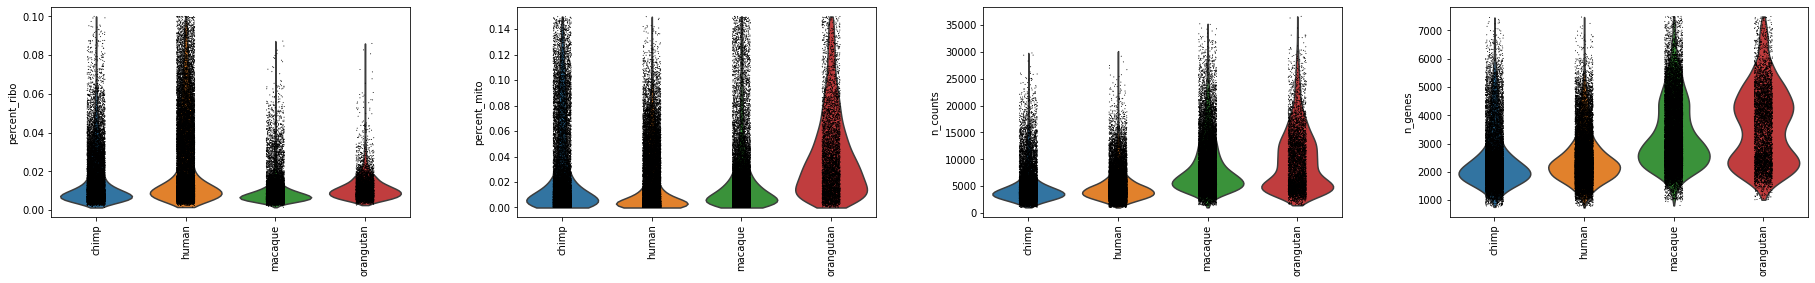

In [12]:
sc.pl.violin(adata,groupby='species',keys=['percent_ribo','percent_mito', 'n_counts', 'n_genes'],  rotation=90, multi_panel=True, 
             save='human_QC_metrics_time_point')

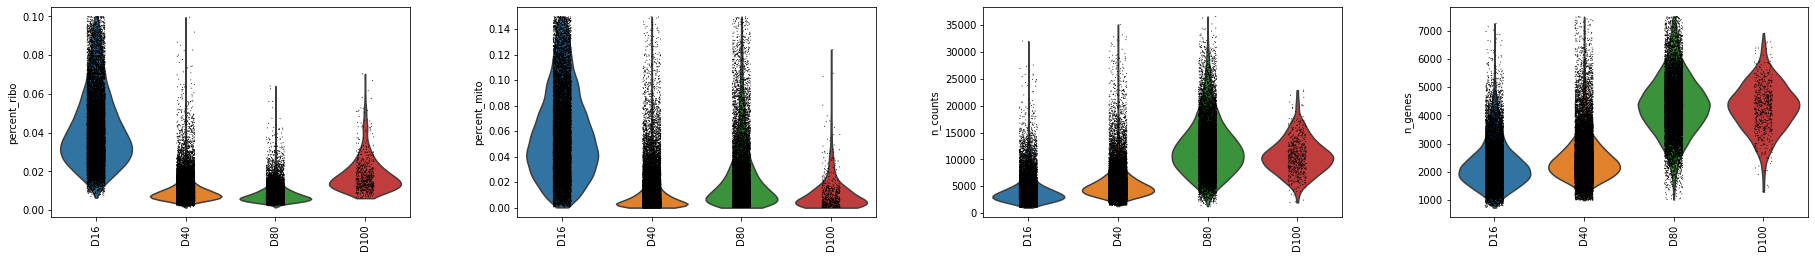

In [13]:
sc.pl.violin(adata,groupby='time_point',keys=['percent_ribo','percent_mito', 'n_counts', 'n_genes'],  rotation=90, multi_panel=True, 
             save='human_QC_metrics_time_point')

# Reconstructing rawdata

In [14]:
rawdata=adata.raw.to_adata()

In [15]:
adata=rawdata

In [16]:
# Total-count normalize (library-size correct) the data matrix 𝐗 to 10,000 reads per cell, so that counts become comparable among cells.
sc.pp.normalize_total(adata, target_sum=1e4)

In [17]:
# Log transform the data
sc.pp.log1p(adata)

In [18]:
# Identify highly-variable genes (HVGs)
(sc.pp.highly_variable_genes(adata,n_top_genes=15000,batch_key='batch',subset=False))

/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:475: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:475: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:510: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

In [19]:
#Scale each gene to unit variance. Clip values exceeding standard deviation 10.
sc.pp.scale(adata, max_value=10)

In [20]:
adata.write(Results_file)

## Principal component analysis

Reduce the dimensionality of the data by running principal component analysis (PCA), which reveals the main axes of variation and denoises the data.

In [21]:
sc.pp.pca(adata,n_comps=50) 


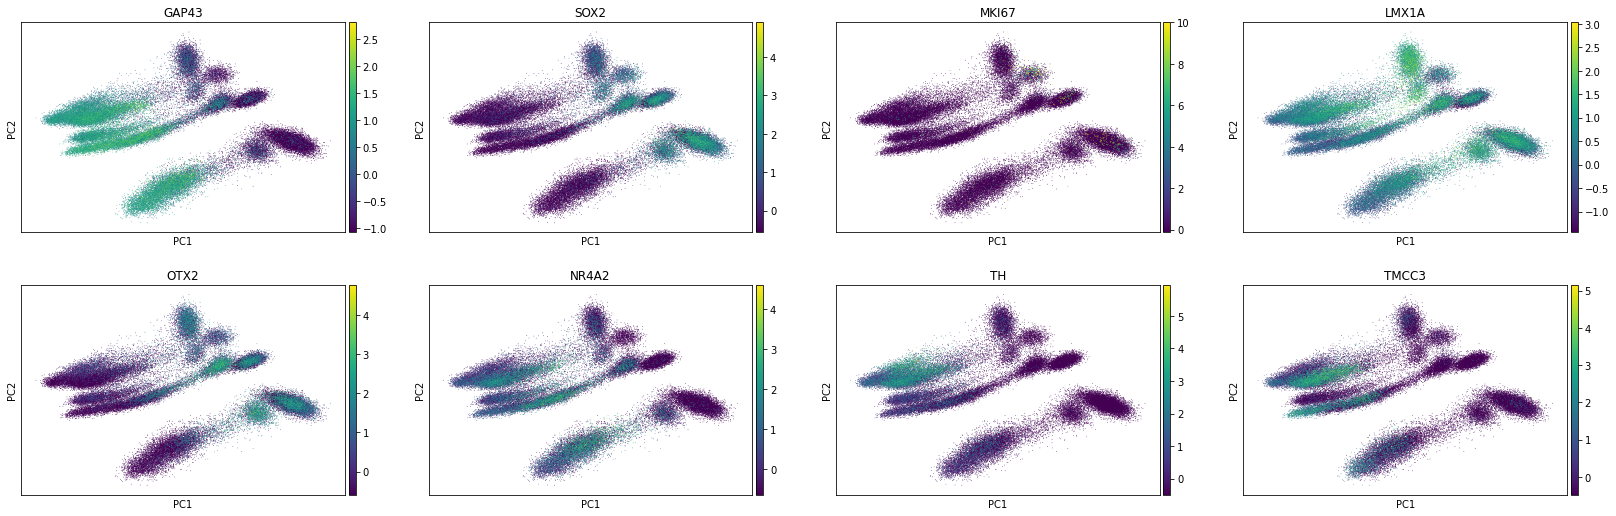

In [22]:
sc.pl.pca(adata, color=(['GAP43',  'SOX2', 'MKI67', 'LMX1A', 'OTX2', 'NR4A2', 'TH', 'TMCC3']))

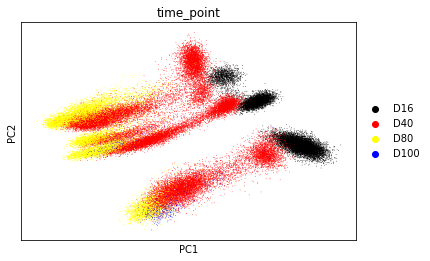

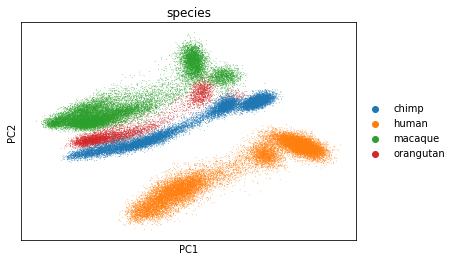

In [23]:
# Scatterplot of PCA coordinates
sc.pl.pca(adata, color='time_point', 
                         palette={
                             "D16": "black",
                             "D40": "red",
                             "D80": "yellow",
                             "D100": 'blue'
                         })

sc.pl.pca(adata, color=(['species']))
                   

In [24]:
adata.uns['time_point_colors'] = ['yellow', 'black','red', 'green']

In [25]:
time_point_colors = adata.uns['time_point_colors'] 

In [26]:
adata.write(Results_file)

## Dotplot of DA progenitors and neurons

In [27]:
adata_DA = adata[adata.obs['supervised_name'].isin(['1. DA neurons', '6. vMB progenitors'
                                                        ])]

In [28]:
DA_list=[
'SOX2',  'OTX2','SOX6', 'FOXA2', 'LMX1A','EN1',
'GAP43', 'TH', 'NR4A2','TMCC3','SLC18A2']

In [31]:
adata_DA.obs['cell_type'] = 'D40-100_DA_neurons'
D16_vMB_progenitors = adata_DA.obs['supervised_name'].str.contains('6. vMB progenitors')
adata_DA.obs.loc[D16_vMB_progenitors, 'cell_type'] = 'D16_vMB_progenitors'

/var/folders/3f/qnn57wjj4f330myjp0cbvc780000gp/T/ipykernel_88785/2873105309.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_DA.obs['cell_type'] = 'D40-100_DA_neurons'


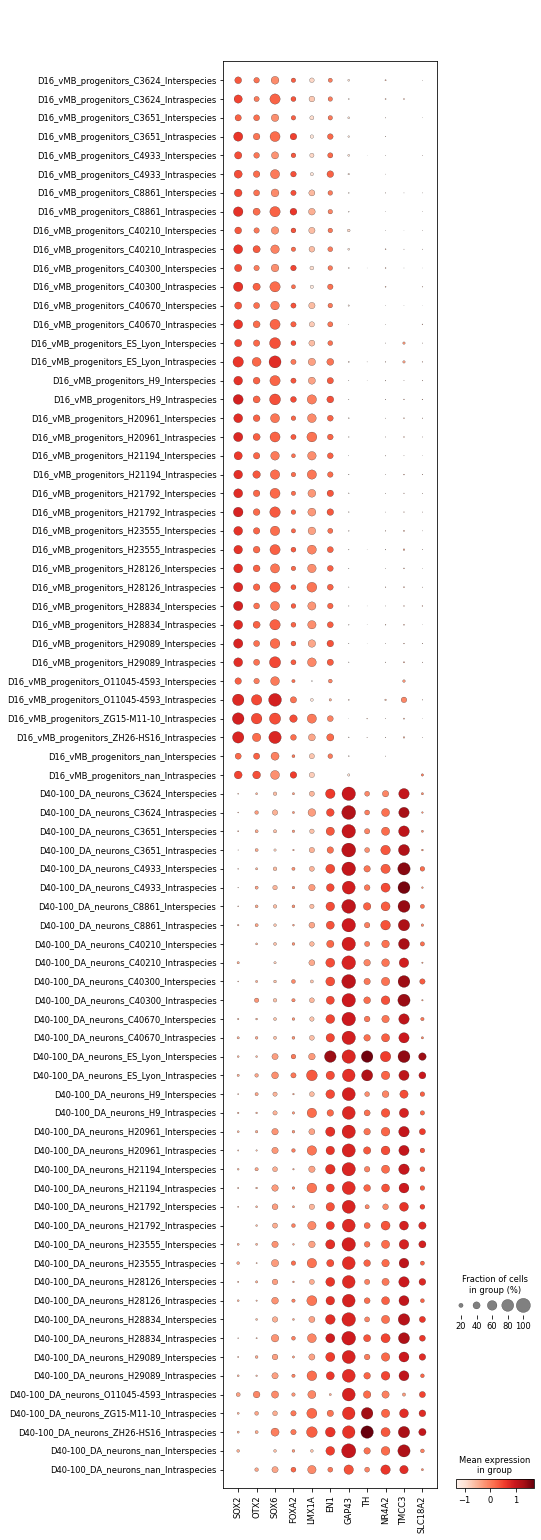

In [32]:
sc.pl.dotplot(adata_DA,  DA_list, groupby=[ 'cell_type', 'individual_pooltype',],  use_raw=False, save='_DA-markers.pdf')